In [3]:
import sys
from pathlib import Path
import json
import shutil
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

from config.config import ActiveLearningConfig
print(f'ActiveLearningConfig is imported')
from src.active_learning import ActiveLearningSystem

PROJECT_ROOT: /home3/vzcl68/Code/Active_Learning_Benchmarking
ActiveLearningConfig is imported


In [4]:
ls "/home3/vzcl68/Datasets/masonry-11"

AL_Plan/           new_pool/            Synthetic_Dataset_18_03_2026.zip
checked_train.txt  pool/                test/
checked_valid.txt  README.dataset.txt   train/
feature/           README.roboflow.txt  Upload/
features/          Syn800.zip           val/


In [6]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

def _list_images(d):
    return [p for p in Path(d).iterdir() if p.suffix in IMG_EXTS]

def prepare_coco_from_yolo_upload(
    upload_dir,
    output_dir,
    copy_images=False
):

    upload_dir = Path(upload_dir)
    output_dir = Path(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    images = []
    annotations = []
    categories = {}

    ann_id = 1
    img_id = 1

    # 🔁 LOOP OVER SUBFOLDERS
    for subfolder in upload_dir.iterdir():

        if not subfolder.is_dir():
            continue

        img_dir = subfolder / "Image"
        lbl_dir = subfolder / "Label"

        if not img_dir.exists() or not lbl_dir.exists():
            print(f"Skipping {subfolder}, missing Image/Label")
            continue

        print(f"Processing {subfolder.name}")

        for img_path in sorted(_list_images(img_dir)):

            img = Image.open(img_path)
            w, h = img.size

            images.append({
                "id": img_id,
                "file_name": img_path.name,
                "width": w,
                "height": h,
            })

            label_file = lbl_dir / f"{img_path.stem}.txt"

            if label_file.exists():

                for line in label_file.read_text().splitlines():

                    parts = line.split()

                    cls = int(parts[0])
                    coords = list(map(float, parts[1:]))

                    categories.setdefault(cls+1, f"class_{cls}")

                    if len(coords) == 4:
                        cx, cy, bw, bh = coords

                        bw *= w
                        bh *= h

                        x = (cx * w) - bw / 2
                        y = (cy * h) - bh / 2

                        segmentation = []

                    else:
                        poly = []
                        for i in range(0, len(coords), 2):
                            px = coords[i] * w
                            py = coords[i+1] * h
                            poly.extend([px, py])

                        xs = poly[0::2]
                        ys = poly[1::2]

                        x = min(xs)
                        y = min(ys)
                        bw = max(xs) - x
                        bh = max(ys) - y

                        segmentation = [poly]

                    annotations.append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": cls+1,
                        "bbox": [x, y, bw, bh],
                        "area": bw * bh,
                        "iscrowd": 0,
                        "segmentation": segmentation
                    })

                    ann_id += 1

            img_id += 1

            # 📦 copy images if needed
            if copy_images:
                shutil.copy(img_path, output_dir / img_path.name)

    coco = {
        "info": {},
        "licenses": [],
        "images": images,
        "annotations": annotations,
        "categories": [
            {"id": cid, "name": name}
            for cid, name in categories.items()
        ],
    }

    out_json = output_dir / "_annotations.coco.json"
    out_json.write_text(json.dumps(coco))

    print(f"COCO file written to {out_json}")

In [7]:
prepare_coco_from_yolo_upload(
    upload_dir="/home3/vzcl68/Datasets/masonry-11/new_pool",
    output_dir="/home3/vzcl68/Datasets/masonry-11/pool2",
    copy_images = True
)

Processing BM
Processing SC
Processing MM
Processing MC
Processing SM
Processing BC
Processing MF
Processing BF
COCO file written to /home3/vzcl68/Datasets/masonry-11/pool2/_annotations.coco.json


In [33]:
config = ActiveLearningConfig()

# ---- dataset ----
config.dataset_type = "coco_instance"   # or deepcrack
config.data_dir = "/home3/vzcl68/Datasets/masonry-11/"
config.img_size = 256
# ---- model ----
config.task = 'instance_segmentation'
config.model_name = "maskrcnn"                  # or "maskrcnn"
config.num_classes = 4

# ---- active learning ----
config.cold_start_strategy = "random"
config.query_strategy = "uncertainty"
config.query_size = 100
config.initial_labeled = 0.1

# ---- training ----
config.epochs = 3
config.batch_size = 4
config.num_workers = 2
config.lr = 1e-3
config.weight_decay = 1e-4


# ---- logging ----
config.use_wandb = False

In [34]:
from src.data_modules.factory import load_dataset
pool_ds = load_dataset(config, split="pool")
train_ds = load_dataset(config, split="train")

loading annotations into memory...
Done (t=0.52s)
creating index...
index created!
loading annotations into memory...
Done (t=0.14s)
creating index...
index created!


In [51]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_NAMES = {
    1: "bricks",
    2: "broken_bricks",
    3: "cracks",
}

CLASS_COLORS = {
    1: (1.0, 0.6, 0.2),   # orange
    2: (1.0, 0.0, 0.0),   # red
    3: (0.0, 1.0, 0.0),   # green
}

def show_coco_instance(dataset, idx=0):

    image, target = dataset[idx]

    image = image.permute(1,2,0).numpy()
    image = np.clip(image,0,1)

    masks = target["masks"].numpy()
    labels = target["labels"].numpy()

    overlay = image.copy()

    for i in range(len(masks)):

        mask = masks[i].astype(bool)
        label = int(labels[i])
        color = np.array(CLASS_COLORS.get(label,(1,1,1)))

        alpha = 0.35

        overlay[mask] = overlay[mask]*(1-alpha) + color*alpha

    fig, ax = plt.subplots(figsize=(8,8))
    ax.imshow(overlay)

    # draw labels
    for i in range(len(masks)):

        mask = masks[i]
        label = int(labels[i])

        ys, xs = np.where(mask>0)
        if len(xs)>0:
            x = int(xs.mean())
            y = int(ys.mean())

            ax.text(
                x, y,
                CLASS_NAMES.get(label,"class"),
                color="white",
                fontsize=11,
                ha="center",
                bbox=dict(
                    facecolor=CLASS_COLORS.get(label,(1,1,1)),
                    alpha=0.9,
                    edgecolor="black"
                )
            )

    ax.axis("off")
    plt.show()

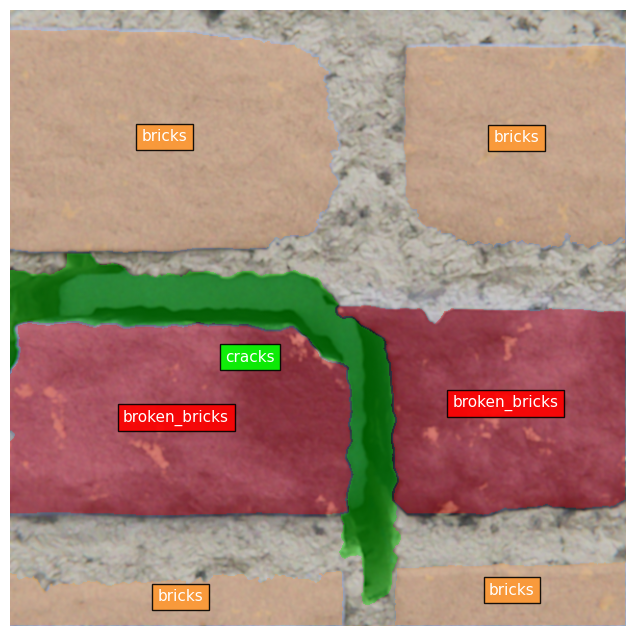

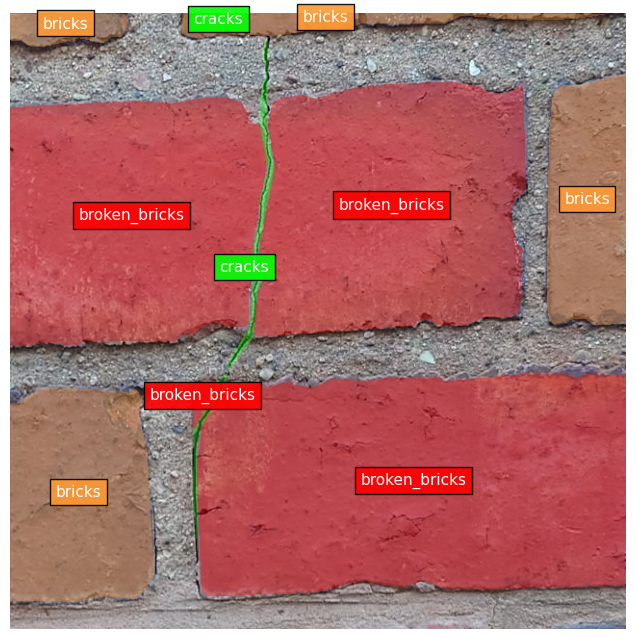

In [59]:
show_coco_instance(pool_ds, 2)
show_coco_instance(train_ds, 2)